In [26]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [27]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA version:", torch.version.cuda)
else:
    print("WARNING: GPU is not available.")

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4
CUDA version: 12.8


In [28]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cuda


In [29]:
import os
import copy
import time
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import (
    efficientnet_b0,
    EfficientNet_B0_Weights,
    resnet50,
    ResNet50_Weights
)

from PIL import Image

In [30]:
print("Libraries imported successfully!")

Libraries imported successfully!


In [31]:
import pandas as pd
from pathlib import Path

DATA_PATH = Path("/content/drive/MyDrive/MediScan/data")
SPLIT_PATH = DATA_PATH / "splits"

train_df = pd.read_csv(SPLIT_PATH / "train.csv")
val_df = pd.read_csv(SPLIT_PATH / "validation.csv")
test_df = pd.read_csv(SPLIT_PATH / "test.csv")

print("Dataset splits loaded successfully!")
print("=" * 50)

print("Training   :", len(train_df))
print("Validation :", len(val_df))
print("Testing    :", len(test_df))
print("Total      :", len(train_df) + len(val_df) + len(test_df))

Dataset splits loaded successfully!
Training   : 5040
Validation : 1080
Testing    : 1080
Total      : 7200


In [32]:
classes = sorted(train_df["class"].unique())

class_to_idx = {
    class_name: idx
    for idx, class_name in enumerate(classes)
}

print("Class Mapping")
print("=" * 50)

for class_name, class_id in class_to_idx.items():
    print(f"{class_id} → {class_name}")

Class Mapping
0 → glioma
1 → meningioma
2 → notumor
3 → pituitary


In [33]:
from torch.utils.data import Dataset
from PIL import Image

class BrainTumorDataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

        self.class_names = sorted(
            self.dataframe["class"].unique()
        )

        self.class_to_idx = {
            class_name: idx
            for idx, class_name in enumerate(self.class_names)
        }

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):

        row = self.dataframe.iloc[index]

        image_path = row["path"]
        class_name = row["class"]

        # Load image as grayscale
        image = Image.open(image_path).convert("L")

        # Convert grayscale to RGB
        image = image.convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = self.class_to_idx[class_name]

        return image, label


print("BrainTumorDataset class created successfully!")

BrainTumorDataset class created successfully!


In [34]:
from torchvision import transforms

# Training transformations
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor()
])

# Validation/Test transformations
val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

print("Training augmentation pipeline created!")
print("Validation/Test preprocessing pipeline created!")

Training augmentation pipeline created!
Validation/Test preprocessing pipeline created!


In [35]:
train_dataset = BrainTumorDataset(
    train_df,
    transform=train_transform
)

val_dataset = BrainTumorDataset(
    val_df,
    transform=val_test_transform
)

test_dataset = BrainTumorDataset(
    test_df,
    transform=val_test_transform
)

print("Datasets created successfully!")
print("=" * 50)

print("Training dataset  :", len(train_dataset))
print("Validation dataset:", len(val_dataset))
print("Testing dataset   :", len(test_dataset))

print("\nClasses:", train_dataset.class_names)
print("Class mapping:", train_dataset.class_to_idx)

Datasets created successfully!
Training dataset  : 5040
Validation dataset: 1080
Testing dataset   : 1080

Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Class mapping: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


In [36]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("DataLoaders recreated successfully!")
print("=" * 50)

print("Training batches  :", len(train_loader))
print("Validation batches:", len(val_loader))
print("Testing batches   :", len(test_loader))

DataLoaders recreated successfully!
Training batches  : 158
Validation batches: 34
Testing batches   : 34


In [37]:
images, labels = next(iter(train_loader))

print("Day 4 DataLoader Verification")
print("=" * 50)

print("Images shape :", images.shape)
print("Labels shape :", labels.shape)
print("Images dtype :", images.dtype)
print("Labels dtype :", labels.dtype)

print("\nPixel range:")
print("Min:", images.min().item())
print("Max:", images.max().item())

print("\nLabels:")
print(labels)

Day 4 DataLoader Verification
Images shape : torch.Size([32, 3, 224, 224])
Labels shape : torch.Size([32])
Images dtype : torch.float32
Labels dtype : torch.int64

Pixel range:
Min: 0.0
Max: 1.0

Labels:
tensor([0, 2, 1, 0, 0, 3, 3, 1, 0, 3, 3, 3, 3, 1, 1, 3, 2, 2, 3, 1, 1, 0, 0, 2,
        1, 1, 0, 0, 1, 0, 0, 2])


In [38]:
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
import torch.nn as nn

# Load pretrained EfficientNet-B0
efficientnet_weights = EfficientNet_B0_Weights.DEFAULT

efficientnet = efficientnet_b0(
    weights=efficientnet_weights
)

# Replace classifier for 4 classes
efficientnet.classifier[1] = nn.Linear(
    efficientnet.classifier[1].in_features,
    4
)

print("EfficientNet-B0 recreated successfully!")
print("Classifier:", efficientnet.classifier)

EfficientNet-B0 recreated successfully!
Classifier: Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=4, bias=True)
)


In [39]:
from torchvision.models import resnet50, ResNet50_Weights

# Load pretrained ResNet50
resnet_weights = ResNet50_Weights.DEFAULT

resnet = resnet50(
    weights=resnet_weights
)

# Replace FC layer for 4-class classification
resnet.fc = nn.Linear(
    resnet.fc.in_features,
    4
)

print("ResNet50 recreated successfully!")
print("FC Layer:", resnet.fc)

ResNet50 recreated successfully!
FC Layer: Linear(in_features=2048, out_features=4, bias=True)


In [40]:
for param in efficientnet.parameters():
    param.requires_grad = False

for param in efficientnet.classifier.parameters():
    param.requires_grad = True

In [41]:
for param in resnet.parameters():
    param.requires_grad = False

for param in resnet.fc.parameters():
    param.requires_grad = True

print("Pretrained layers frozen successfully!")

Pretrained layers frozen successfully!


In [42]:
efficientnet = efficientnet.to(device)
resnet = resnet.to(device)

print("Models moved to:", device)

Models moved to: cuda


In [43]:
def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )
    frozen = total - trainable

    return total, trainable, frozen


eff_total, eff_trainable, eff_frozen = count_parameters(efficientnet)
res_total, res_trainable, res_frozen = count_parameters(resnet)

print("Parameter Verification")
print("=" * 50)

print("EfficientNet-B0")
print("Total parameters    :", eff_total)
print("Trainable parameters:", eff_trainable)
print("Frozen parameters   :", eff_frozen)

print("\nResNet50")
print("Total parameters    :", res_total)
print("Trainable parameters:", res_trainable)
print("Frozen parameters   :", res_frozen)

Parameter Verification
EfficientNet-B0
Total parameters    : 4012672
Trainable parameters: 5124
Frozen parameters   : 4007548

ResNet50
Total parameters    : 23516228
Trainable parameters: 8196
Frozen parameters   : 23508032


In [44]:
criterion = nn.CrossEntropyLoss()

print("Loss Function:")
print(criterion)

Loss Function:
CrossEntropyLoss()


In [45]:
import torch.optim as optim

efficientnet_optimizer = optim.Adam(
    filter(
        lambda p: p.requires_grad,
        efficientnet.parameters()
    ),
    lr=0.001
)

resnet_optimizer = optim.Adam(
    filter(
        lambda p: p.requires_grad,
        resnet.parameters()
    ),
    lr=0.001
)

print("Optimizers created successfully!")
print("=" * 50)

print("EfficientNet-B0 Optimizer: Adam, lr=0.001")
print("ResNet50 Optimizer       : Adam, lr=0.001")

Optimizers created successfully!
EfficientNet-B0 Optimizer: Adam, lr=0.001
ResNet50 Optimizer       : Adam, lr=0.001


In [46]:
efficientnet.eval()
resnet.eval()

images, labels = next(iter(train_loader))

images = images.to(device)
labels = labels.to(device)

with torch.no_grad():
    efficientnet_outputs = efficientnet(images)
    resnet_outputs = resnet(images)

print("Final Pre-Training Verification")
print("=" * 50)

print("Input shape:", images.shape)

print("\nEfficientNet-B0")
print("Output shape:", efficientnet_outputs.shape)
print("Output dtype:", efficientnet_outputs.dtype)

print("\nResNet50")
print("Output shape:", resnet_outputs.shape)
print("Output dtype:", resnet_outputs.dtype)

print("\nLabels shape:", labels.shape)
print("Labels dtype:", labels.dtype)

Final Pre-Training Verification
Input shape: torch.Size([32, 3, 224, 224])

EfficientNet-B0
Output shape: torch.Size([32, 4])
Output dtype: torch.float32

ResNet50
Output shape: torch.Size([32, 4])
Output dtype: torch.float32

Labels shape: torch.Size([32])
Labels dtype: torch.int64


In [47]:
def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    num_epochs=10
):

    best_val_accuracy = 0.0
    best_model_weights = copy.deepcopy(model.state_dict())

    history = {
        "train_loss": [],
        "train_accuracy": [],
        "val_loss": [],
        "val_accuracy": []
    }

    for epoch in range(num_epochs):

        # ==========================================
        # TRAINING
        # ==========================================
        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            # Clear gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(images)

            # Calculate loss
            loss = criterion(outputs, labels)

            # Backpropagation
            loss.backward()

            # Update weights
            optimizer.step()

            # Statistics
            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / total
        train_accuracy = 100 * correct / total


        # ==========================================
        # VALIDATION
        # ==========================================
        model.eval()

        val_running_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)

                loss = criterion(outputs, labels)

                val_running_loss += loss.item() * images.size(0)

                _, predicted = torch.max(outputs, 1)

                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_loss = val_running_loss / val_total
        val_accuracy = 100 * val_correct / val_total


        # ==========================================
        # SAVE HISTORY
        # ==========================================
        history["train_loss"].append(train_loss)
        history["train_accuracy"].append(train_accuracy)

        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_accuracy)


        # ==========================================
        # SAVE BEST MODEL
        # ==========================================
        if val_accuracy > best_val_accuracy:

            best_val_accuracy = val_accuracy

            best_model_weights = copy.deepcopy(
                model.state_dict()
            )


        # ==========================================
        # PRINT RESULTS
        # ==========================================
        print(
            f"Epoch [{epoch + 1}/{num_epochs}] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:.2f}% | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_accuracy:.2f}%"
        )


    # Restore best model
    model.load_state_dict(best_model_weights)

    print("\nTraining completed!")
    print(f"Best Validation Accuracy: {best_val_accuracy:.2f}%")

    return model, history

In [48]:
test_model = copy.deepcopy(efficientnet)

test_optimizer = optim.Adam(
    filter(
        lambda p: p.requires_grad,
        test_model.parameters()
    ),
    lr=0.001
)

test_model = test_model.to(device)

print("Running 1-epoch training test...")
print("=" * 60)

test_model, test_history = train_model(
    model=test_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=test_optimizer,
    device=device,
    num_epochs=1
)

Running 1-epoch training test...
Epoch [1/1] | Train Loss: 0.6605 | Train Acc: 78.95% | Val Loss: 0.4742 | Val Acc: 84.63%

Training completed!
Best Validation Accuracy: 84.63%


In [49]:
# Create a fresh pretrained EfficientNet-B0

efficientnet = efficientnet_b0(
    weights=EfficientNet_B0_Weights.DEFAULT
)

# Replace classifier for 4 classes
efficientnet.classifier[1] = nn.Linear(
    efficientnet.classifier[1].in_features,
    4
)

# Freeze pretrained layers
for param in efficientnet.parameters():
    param.requires_grad = False

# Unfreeze classifier
for param in efficientnet.classifier.parameters():
    param.requires_grad = True

# Move to GPU
efficientnet = efficientnet.to(device)

# Create optimizer
efficientnet_optimizer = optim.Adam(
    filter(
        lambda p: p.requires_grad,
        efficientnet.parameters()
    ),
    lr=0.001
)

print("Fresh EfficientNet-B0 ready for training!")

Fresh EfficientNet-B0 ready for training!


In [50]:
efficientnet, efficientnet_history = train_model(
    model=efficientnet,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=efficientnet_optimizer,
    device=device,
    num_epochs=10
)

Epoch [1/10] | Train Loss: 0.6631 | Train Acc: 78.21% | Val Loss: 0.4712 | Val Acc: 85.46%
Epoch [2/10] | Train Loss: 0.4387 | Train Acc: 84.80% | Val Loss: 0.4124 | Val Acc: 86.11%
Epoch [3/10] | Train Loss: 0.3930 | Train Acc: 86.49% | Val Loss: 0.3884 | Val Acc: 86.76%
Epoch [4/10] | Train Loss: 0.3771 | Train Acc: 87.04% | Val Loss: 0.3749 | Val Acc: 87.69%
Epoch [5/10] | Train Loss: 0.3699 | Train Acc: 87.30% | Val Loss: 0.3517 | Val Acc: 87.78%
Epoch [6/10] | Train Loss: 0.3537 | Train Acc: 87.02% | Val Loss: 0.3500 | Val Acc: 88.70%
Epoch [7/10] | Train Loss: 0.3370 | Train Acc: 88.15% | Val Loss: 0.3310 | Val Acc: 88.61%
Epoch [8/10] | Train Loss: 0.3308 | Train Acc: 88.35% | Val Loss: 0.3256 | Val Acc: 88.61%
Epoch [9/10] | Train Loss: 0.3293 | Train Acc: 88.21% | Val Loss: 0.3361 | Val Acc: 88.52%
Epoch [10/10] | Train Loss: 0.3299 | Train Acc: 88.12% | Val Loss: 0.3249 | Val Acc: 88.80%

Training completed!
Best Validation Accuracy: 88.80%


In [51]:
import os
import torch

MODEL_DIR = "/content/drive/MyDrive/MediScan/models"

os.makedirs(MODEL_DIR, exist_ok=True)

efficientnet_path = os.path.join(
    MODEL_DIR,
    "efficientnet_b0_best.pth"
)

torch.save(
    efficientnet.state_dict(),
    efficientnet_path
)

print("EfficientNet-B0 best model saved successfully!")
print("Path:", efficientnet_path)

EfficientNet-B0 best model saved successfully!
Path: /content/drive/MyDrive/MediScan/models/efficientnet_b0_best.pth


In [52]:
import json

history_path = os.path.join(
    MODEL_DIR,
    "efficientnet_b0_history.json"
)

with open(history_path, "w") as f:
    json.dump(efficientnet_history, f)

print("Training history saved successfully!")
print("Path:", history_path)

Training history saved successfully!
Path: /content/drive/MyDrive/MediScan/models/efficientnet_b0_history.json


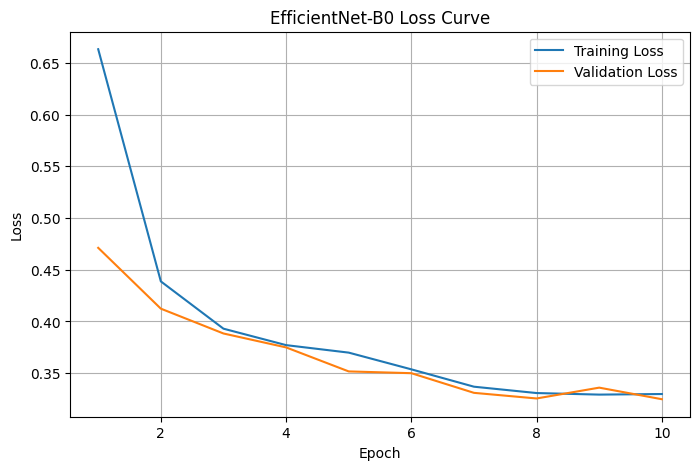

In [53]:
import matplotlib.pyplot as plt

epochs = range(1, len(efficientnet_history["train_loss"]) + 1)

# Loss Curve
plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    efficientnet_history["train_loss"],
    label="Training Loss"
)

plt.plot(
    epochs,
    efficientnet_history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("EfficientNet-B0 Loss Curve")
plt.legend()
plt.grid(True)

plt.show()

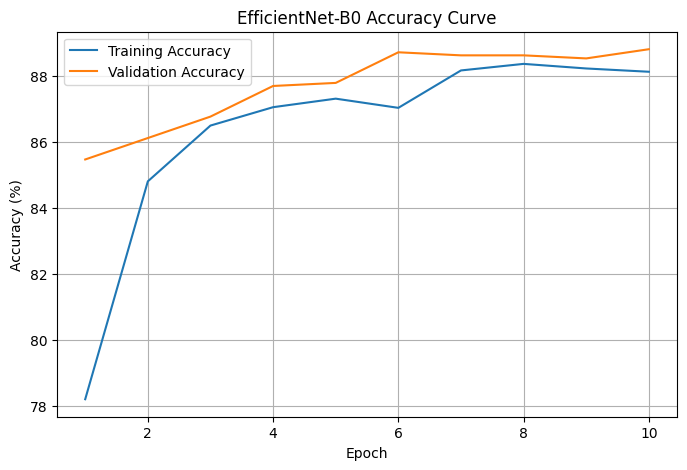

In [54]:
# Accuracy Curve
plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    efficientnet_history["train_accuracy"],
    label="Training Accuracy"
)

plt.plot(
    epochs,
    efficientnet_history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("EfficientNet-B0 Accuracy Curve")
plt.legend()
plt.grid(True)

plt.show()

In [55]:
# Create fresh pretrained ResNet50

resnet = resnet50(
    weights=ResNet50_Weights.DEFAULT
)

# Replace FC layer for 4 classes
resnet.fc = nn.Linear(
    resnet.fc.in_features,
    4
)

# Freeze all pretrained layers
for param in resnet.parameters():
    param.requires_grad = False

# Unfreeze final FC layer
for param in resnet.fc.parameters():
    param.requires_grad = True

# Move model to GPU
resnet = resnet.to(device)

# Create optimizer
resnet_optimizer = optim.Adam(
    filter(
        lambda p: p.requires_grad,
        resnet.parameters()
    ),
    lr=0.001
)

print("Fresh ResNet50 ready for training!")

Fresh ResNet50 ready for training!


In [56]:
res_total, res_trainable, res_frozen = count_parameters(resnet)

print("ResNet50 Parameter Verification")
print("=" * 50)

print("Total parameters    :", res_total)
print("Trainable parameters:", res_trainable)
print("Frozen parameters   :", res_frozen)

ResNet50 Parameter Verification
Total parameters    : 23516228
Trainable parameters: 8196
Frozen parameters   : 23508032


In [57]:
resnet, resnet_history = train_model(
    model=resnet,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=resnet_optimizer,
    device=device,
    num_epochs=10
)

Epoch [1/10] | Train Loss: 0.7555 | Train Acc: 76.33% | Val Loss: 0.6367 | Val Acc: 81.57%
Epoch [2/10] | Train Loss: 0.4781 | Train Acc: 84.35% | Val Loss: 0.5031 | Val Acc: 84.26%
Epoch [3/10] | Train Loss: 0.4245 | Train Acc: 85.36% | Val Loss: 0.4351 | Val Acc: 86.11%
Epoch [4/10] | Train Loss: 0.3922 | Train Acc: 86.77% | Val Loss: 0.4220 | Val Acc: 86.11%
Epoch [5/10] | Train Loss: 0.3573 | Train Acc: 87.40% | Val Loss: 0.4111 | Val Acc: 85.65%
Epoch [6/10] | Train Loss: 0.3489 | Train Acc: 88.13% | Val Loss: 0.3935 | Val Acc: 86.48%
Epoch [7/10] | Train Loss: 0.3263 | Train Acc: 88.89% | Val Loss: 0.3797 | Val Acc: 86.76%
Epoch [8/10] | Train Loss: 0.3261 | Train Acc: 88.29% | Val Loss: 0.3579 | Val Acc: 88.15%
Epoch [9/10] | Train Loss: 0.3012 | Train Acc: 89.60% | Val Loss: 0.3632 | Val Acc: 87.59%
Epoch [10/10] | Train Loss: 0.3026 | Train Acc: 89.23% | Val Loss: 0.3391 | Val Acc: 88.33%

Training completed!
Best Validation Accuracy: 88.33%


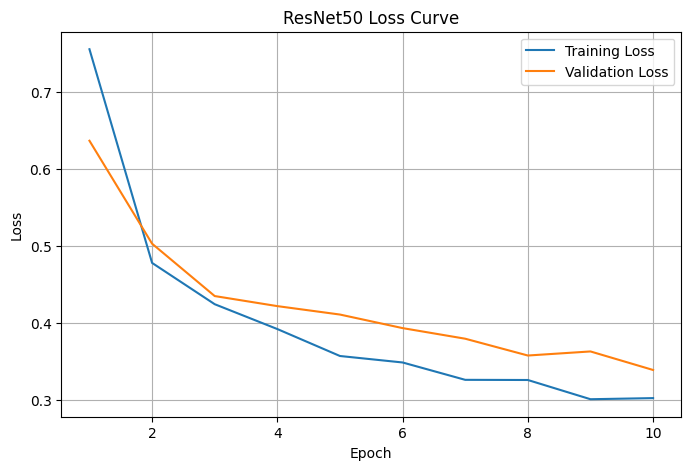

In [58]:
import matplotlib.pyplot as plt

epochs = range(1, len(resnet_history["train_loss"]) + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    resnet_history["train_loss"],
    label="Training Loss"
)

plt.plot(
    epochs,
    resnet_history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet50 Loss Curve")
plt.legend()
plt.grid(True)

plt.show()

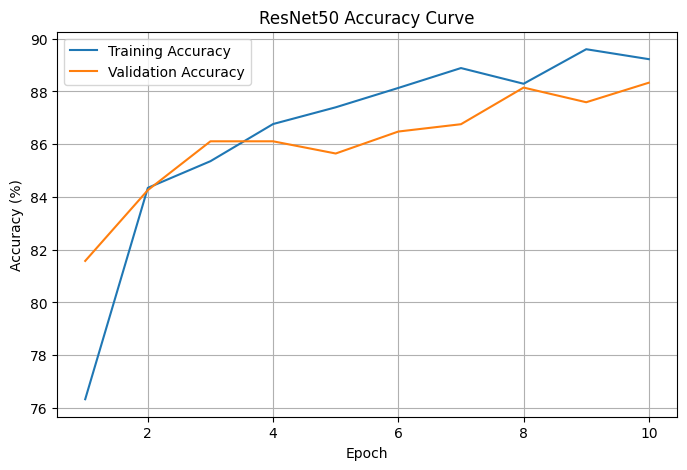

In [59]:
plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    resnet_history["train_accuracy"],
    label="Training Accuracy"
)

plt.plot(
    epochs,
    resnet_history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("ResNet50 Accuracy Curve")
plt.legend()
plt.grid(True)

plt.show()

In [60]:
resnet_path = os.path.join(
    MODEL_DIR,
    "resnet50_best.pth"
)

torch.save(
    resnet.state_dict(),
    resnet_path
)

print("ResNet50 best model saved successfully!")
print("Path:", resnet_path)

ResNet50 best model saved successfully!
Path: /content/drive/MyDrive/MediScan/models/resnet50_best.pth


In [61]:
resnet_history_path = os.path.join(
    MODEL_DIR,
    "resnet50_history.json"
)

with open(resnet_history_path, "w") as f:
    json.dump(resnet_history, f)

print("ResNet50 training history saved successfully!")
print("Path:", resnet_history_path)

ResNet50 training history saved successfully!
Path: /content/drive/MyDrive/MediScan/models/resnet50_history.json


In [62]:
import os

MODEL_DIR = "/content/drive/MyDrive/MediScan/models"

print("Files in models folder:")
print("=" * 50)

for file in os.listdir(MODEL_DIR):
    print(file)

Files in models folder:
efficientnet_b0_best.pth
efficientnet_b0_history.json
resnet50_best.pth
resnet50_history.json


In [63]:
import os

required_files = [
    "efficientnet_b0_best.pth",
    "efficientnet_b0_history.json",
    "resnet50_best.pth",
    "resnet50_history.json"
]

print("Model Files Verification")
print("=" * 60)

for file in required_files:
    path = os.path.join(MODEL_DIR, file)

    if os.path.exists(path):
        size_mb = os.path.getsize(path) / (1024 * 1024)
        print(f"✅ {file} — {size_mb:.2f} MB")
    else:
        print(f"❌ {file} — NOT FOUND")

Model Files Verification
✅ efficientnet_b0_best.pth — 15.60 MB
✅ efficientnet_b0_history.json — 0.00 MB
✅ resnet50_best.pth — 90.01 MB
✅ resnet50_history.json — 0.00 MB
